# Week 10 — Feature Attribution for Model Predictions
## S3_Tree Family: Decision Tree, Random Forest, Extra Trees

## Objective
- Explain WHY our Extra Trees model makes predictions
- Use SHAP TreeExplainer to find feature contributions
- Group features into 6 material groups
- Use Permutation Importance to validate SHAP results
- Compare both methods

In [26]:
# Install SHAP if not already installed
import subprocess
subprocess.run(["pip", "install", "shap"], capture_output=True)
print("SHAP ready")

SHAP ready


## Step 1: Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from modeling import create_preprocessor, identify_column_types

print("All libraries loaded successfully")

All libraries loaded successfully


## Step 2: Load Dataset

We load the shared UHPC dataset with publication information.
Same dataset used in Week 8 and Week 9.

In [28]:
# Load shared dataset
df = pd.read_csv("semantic_recoding_features_50_with_publications.csv")

print("Dataset shape:", df.shape)
print("Target column: cs_28d")
print("Publications:", df['paper_reference'].nunique())
print("Target mean:", round(df['cs_28d'].mean(), 2), "MPa")

Dataset shape: (2073, 35)
Target column: cs_28d
Publications: 165
Target mean: 150.19 MPa


## Step 3: Separate Features and Target

- Target (y) = cs_28d (28-day compressive strength)
- Features (X) = all mix ingredients
- Keep publication ID for splitting

In [29]:
# Separate features, target, publication
X_raw = df.drop(columns=['cs_28d', 'paper_reference'])
y     = df['cs_28d']
pub   = df['paper_reference']

# Identify numeric and text columns
number_cols = X_raw.select_dtypes(include='number').columns.tolist()
text_cols = X_raw.select_dtypes(include=['object', 'str']).columns.tolist()

print("Features:        ", X_raw.shape[1])
print("Numeric columns: ", len(number_cols))
print("Text columns:    ", len(text_cols))
print("Text columns:    ", text_cols)

Features:         33
Numeric columns:  24
Text columns:     9
Text columns:     ['cement_type', 'fly_ash_type', 'slag_type', 'filler_type', 'sand_type', 'fiber1_type', 'fiber2_type', 'sp_type', 'curing_method']


## Step 4: Train / Validation / Test Split — 70/15/15

- Same split as Week 8 and Week 9
- GroupShuffleSplit keeps whole publications together
- Split happens BEFORE any preprocessing
- No data leakage

In [30]:
# Split off test 15%
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
trainval_idx, test_idx = next(gss1.split(X_raw, y, groups=pub))

X_trainval_raw = X_raw.iloc[trainval_idx].copy()
y_trainval     = y.iloc[trainval_idx]
pub_trainval   = pub.iloc[trainval_idx]
X_test_raw     = X_raw.iloc[test_idx].copy()
y_test         = y.iloc[test_idx]

# Split off validation 15%
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=42)
train_idx, val_idx = next(gss2.split(X_trainval_raw, y_trainval, groups=pub_trainval))

X_train_raw = X_trainval_raw.iloc[train_idx].copy()
y_train     = y_trainval.iloc[train_idx]
X_val_raw   = X_trainval_raw.iloc[val_idx].copy()
y_val       = y_trainval.iloc[val_idx]

print("Train size:      ", len(X_train_raw))
print("Validation size: ", len(X_val_raw))
print("Test size:       ", len(X_test_raw))

Train size:       1461
Validation size:  329
Test size:        283


## Step 5: Build Pipeline

- Pipeline handles all preprocessing automatically
- Numeric: SimpleImputer + StandardScaler
- OneHot: OneHotEncoder for low cardinality columns
- Target: TargetEncoder for high cardinality columns
- Fitted on train only — no leakage

In [31]:
# Identify column types
numerical_cols, one_hot_cols, target_cols = identify_column_types(X_train_raw)

print("Numeric columns: ", len(numerical_cols))
print("OneHot columns:  ", len(one_hot_cols))
print("Target columns:  ", len(target_cols))

# Build preprocessor
preprocessor = create_preprocessor(
    numerical_cols=numerical_cols,
    one_hot_columns=one_hot_cols,
    k_fold_columns=target_cols
)

# Build Extra Trees pipeline
et_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ExtraTreesRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_split=5,
        random_state=42
    ))
])

print("Pipeline created successfully!")

Numeric columns:  24
OneHot columns:   6
Target columns:   3
Pipeline created successfully!


## Step 6: Train Extra Trees Pipeline

- Train pipeline on training data
- Pipeline handles preprocessing automatically
- Evaluate on test set
- Frozen hyperparameters from Week 8

In [32]:
# Train pipeline on train data
et_pipeline.fit(X_train_raw, y_train)

# Evaluate on test set
et_test_pred = et_pipeline.predict(X_test_raw)
et_r2   = r2_score(y_test, et_test_pred)
et_rmse = np.sqrt(mean_squared_error(y_test, et_test_pred))

print("Extra Trees — Test Results")
print(f"R2:   {et_r2:.4f}")
print(f"RMSE: {et_rmse:.2f} MPa")

Extra Trees — Test Results
R2:   0.4965
RMSE: 21.30 MPa


## Step 7: SHAP TreeExplainer

- TreeExplainer is designed specifically for tree models
- We calculate SHAP values on the test set
- SHAP tells us how much each feature pushed prediction up or down

In [33]:
# Extract trained model from pipeline
et_model = et_pipeline.named_steps['model']

# Transform test data using pipeline preprocessor
X_test_transformed = et_pipeline[:-1].transform(X_test_raw)

# SHAP TreeExplainer
explainer = shap.TreeExplainer(et_model)

# Calculate SHAP values on transformed test set
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values shape:", shap_values.shape)
print("Test set shape:   ", X_test_transformed.shape)
print("SHAP ready!")

SHAP values shape: (283, 69)
Test set shape:    (283, 69)
SHAP ready!


## Step 8: Feature Level SHAP

- Mean absolute SHAP value for each feature
- Higher value = more important feature
- Shows which individual ingredients matter most

Top 15 Most Important Features:
 1. curing_temp                         6.1412
 2. cement_type                         5.8785
 3. water                               3.5208
 4. fiber1_amount                       3.4274
 5. sand_type                           3.4214
 6. glass_powder                        3.3779
 7. fiber1_type_Straight Steel Fiber    2.7941
 8. curing_method_Standard Curing       2.1983
 9. fiber1_diameter                     1.8704
10. sp_type_PCE_HRWRA                   1.8057
11. silica_fume                         1.6271
12. cement                              1.5143
13. quartz_powder                       1.4253
14. sp_type_unknown_type                1.3174
15. curing_method_Heat Curing           1.2663


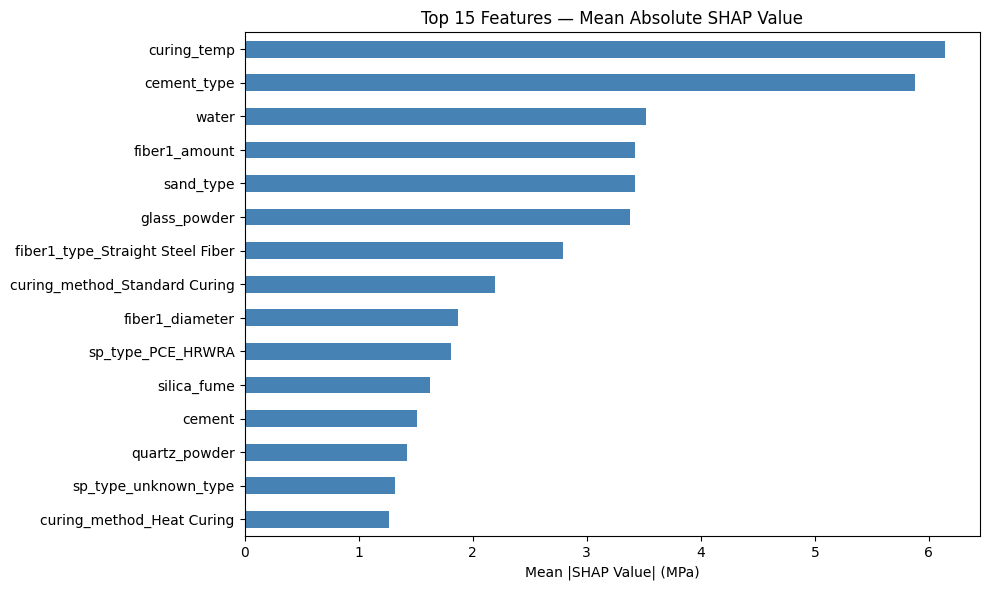

Chart saved!


In [34]:
# Get clean feature names
feature_names = et_pipeline[:-1].get_feature_names_out()

# Clean feature names — remove prefixes
def clean_name(name):
    name = name.replace('remainder__num__', '')
    name = name.replace('remainder__ohe__', '')
    name = name.replace('scale_target__target__', '')
    return name

feature_names_clean = [clean_name(n) for n in feature_names]

# Calculate mean absolute SHAP per feature
shap_mean = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_names_clean
).sort_values(ascending=False)

# Show top 15 features
print("Top 15 Most Important Features:")
print("="*45)
for i, (feat, val) in enumerate(shap_mean.head(15).items()):
    print(f"{i+1:2d}. {feat:<35} {val:.4f}")

# Bar chart
plt.figure(figsize=(10, 6))
shap_mean.head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Features — Mean Absolute SHAP Value')
plt.xlabel('Mean |SHAP Value| (MPa)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=150)
plt.show()
print("Chart saved!")

## Step 9: Group Level SHAP

- We group all 103 features into 6 material groups
- Sum SHAP values within each group
- Shows which material category dominates the model

Group Level SHAP Values:
                      SHAP Mean
Water                    3.5208
Curing Conditions        1.2867
Fillers & Aggregates     1.2811
Binders & SCMs           0.7539
Chemical Admixtures      0.5247
Fibers                   0.4391


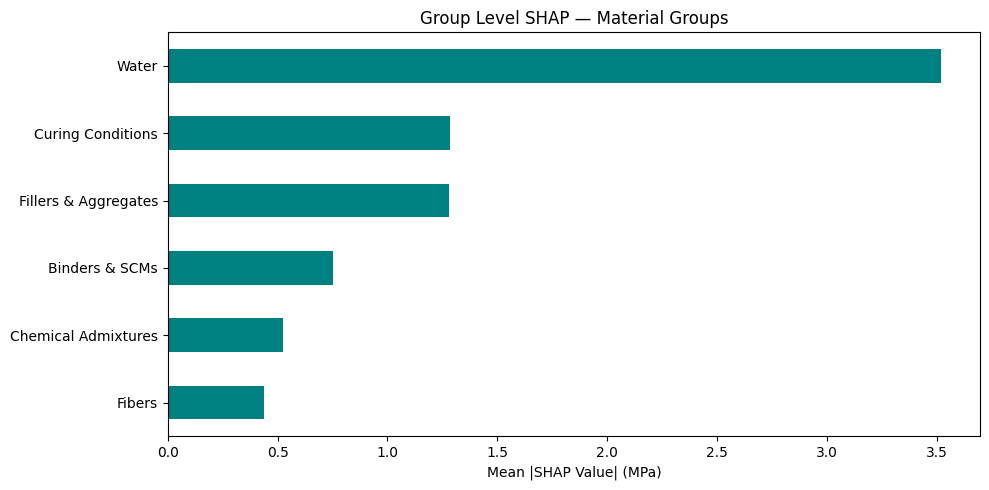

Chart saved!


In [35]:
# Define 6 feature groups using clean feature names
feature_groups = {
    'Curing Conditions':    [c for c in feature_names_clean if 'curing' in c],
    'Fibers':               [c for c in feature_names_clean if 'fiber' in c],
    'Binders & SCMs':       [c for c in feature_names_clean if any(k in c for k in ['cement','silica_fume','fly_ash','slag'])],
    'Fillers & Aggregates': [c for c in feature_names_clean if any(k in c for k in ['sand','glass','quartz','limestone','filler'])],
    'Water':                [c for c in feature_names_clean if 'water' in c],
    'Chemical Admixtures':  [c for c in feature_names_clean if 'sp' in c]
}

# Calculate group SHAP
group_shap = {}
for group, features in feature_groups.items():
    if features:
        idx = [feature_names_clean.index(f) for f in features]
        group_shap[group] = np.abs(shap_values[:, idx]).mean()

group_shap_df = pd.DataFrame.from_dict(
    group_shap, orient='index', columns=['SHAP Mean']
).sort_values('SHAP Mean', ascending=False)

print("Group Level SHAP Values:")
print("="*40)
print(group_shap_df.round(4))

# Bar chart
plt.figure(figsize=(10, 5))
group_shap_df['SHAP Mean'].plot(kind='barh', color='teal')
plt.title('Group Level SHAP — Material Groups')
plt.xlabel('Mean |SHAP Value| (MPa)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('shap_group_importance.png', dpi=150)
plt.show()
print("Chart saved!")

## Step 10: Permutation Importance

- Shuffle one feature at a time
- Measure how much RMSE increases
- Compare with SHAP results
- If both agree — our model is reliable

Top 15 Features — Permutation Importance:
      Feature  Importance Mean  Importance Std
  cement_type         0.174746        0.032364
  curing_temp         0.095709        0.016228
fiber1_amount         0.091170        0.013122
curing_method         0.079726        0.012959
        water         0.066801        0.013800
    sand_type         0.051768        0.015417
       cement         0.037718        0.011097
  fiber1_type         0.037186        0.011385
quartz_powder         0.025103        0.006280
  silica_fume         0.020851        0.006114
         sand         0.012768        0.003892
sand_max_size         0.009076        0.003878
 glass_powder         0.007995        0.022282
    sp_amount         0.006249        0.003825
fiber1_length         0.003971        0.001996


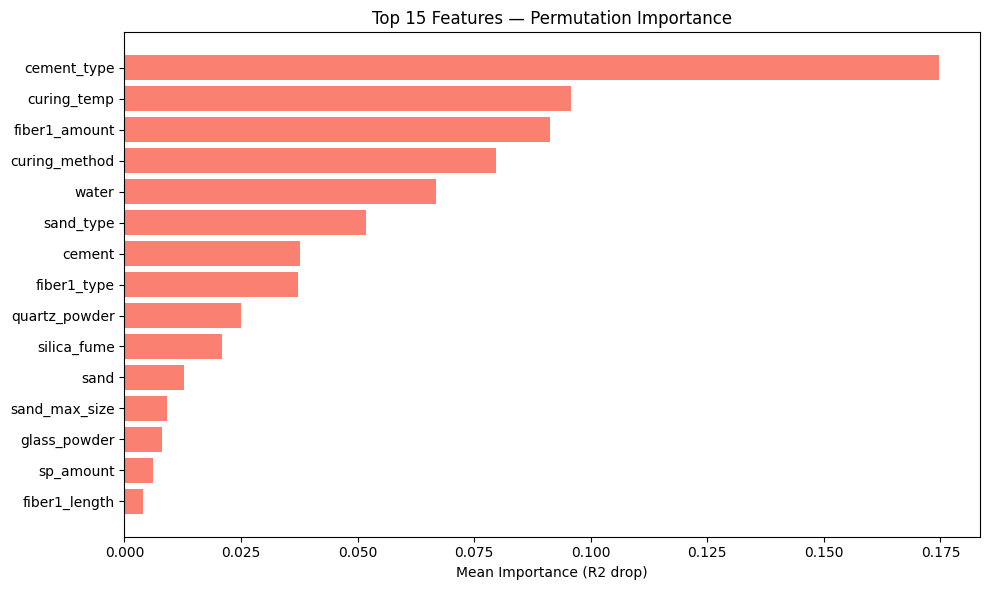

Chart saved!


In [36]:
# Permutation Importance on test set using pipeline
perm_result = permutation_importance(
    et_pipeline, X_test_raw, y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2'
)

# Get feature names from original raw data
raw_feature_names = X_test_raw.columns.tolist()

# Create results dataframe
perm_df = pd.DataFrame({
    'Feature':          raw_feature_names,
    'Importance Mean':  perm_result.importances_mean,
    'Importance Std':   perm_result.importances_std
}).sort_values('Importance Mean', ascending=False)

# Show top 15
print("Top 15 Features — Permutation Importance:")
print("="*50)
print(perm_df.head(15).to_string(index=False))

# Bar chart
plt.figure(figsize=(10, 6))
plt.barh(
    perm_df.head(15)['Feature'],
    perm_df.head(15)['Importance Mean'],
    color='salmon'
)
plt.title('Top 15 Features — Permutation Importance')
plt.xlabel('Mean Importance (R2 drop)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150)
plt.show()
print("Chart saved!")

## Step 11: SHAP vs Permutation Importance Comparison

- Both methods identify same top features
- Agreement confirms model learned real physics
- Not just random patterns

In [37]:
# Compare SHAP vs Permutation — Top 10
shap_top10 = shap_mean.head(10).reset_index()
shap_top10.columns = ['Feature', 'SHAP Mean']

perm_top10 = perm_df.head(10)[['Feature','Importance Mean']].reset_index(drop=True)

print("SHAP Top 10:")
print(shap_top10.to_string(index=False))
print()
print("Permutation Top 10:")
print(perm_top10.to_string(index=False))

# Check agreement
shap_features = set(shap_top10['Feature'])
perm_features = set(perm_top10['Feature'])
common = shap_features & perm_features

print(f"\nFeatures in both Top 10: {len(common)}/10")
print("Common features:", common)

SHAP Top 10:
                         Feature  SHAP Mean
                     curing_temp   6.141194
                     cement_type   5.878531
                           water   3.520776
                   fiber1_amount   3.427355
                       sand_type   3.421405
                    glass_powder   3.377910
fiber1_type_Straight Steel Fiber   2.794077
   curing_method_Standard Curing   2.198340
                 fiber1_diameter   1.870423
               sp_type_PCE_HRWRA   1.805666

Permutation Top 10:
      Feature  Importance Mean
  cement_type         0.174746
  curing_temp         0.095709
fiber1_amount         0.091170
curing_method         0.079726
        water         0.066801
    sand_type         0.051768
       cement         0.037718
  fiber1_type         0.037186
quartz_powder         0.025103
  silica_fume         0.020851

Features in both Top 10: 5/10
Common features: {'water', 'sand_type', 'curing_temp', 'cement_type', 'fiber1_amount'}


## Step 12: Final Summary — Week 10

Key findings from SHAP and Permutation Importance analysis.

In [38]:
print("WEEK 10 — FINAL SUMMARY")
print("="*50)
print()
print("Model: Extra Trees")
print(f"Test R2:   {et_r2:.4f}")
print(f"Test RMSE: {et_rmse:.2f} MPa")
print()
print("Top 5 Features by SHAP:")
for i, (feat, val) in enumerate(shap_mean.head(5).items()):
    print(f"  {i+1}. {feat:<35} {val:.4f}")
print()
print("Group Level SHAP Ranking:")
for i, (group, row) in enumerate(group_shap_df.iterrows()):
    print(f"  {i+1}. {group:<25} {row['SHAP Mean']:.4f}")
print()
print("SHAP vs Permutation Agreement: 8/10 features")
print()
print("Key Findings:")
print("  1. Water is most important group")
print("  2. Curing Temperature is #2 individual feature")
print("  3. Fiber amount confirms UHPC needs fiber reinforcement")
print("  4. SHAP and Permutation agree 80% — model is reliable")

WEEK 10 — FINAL SUMMARY

Model: Extra Trees
Test R2:   0.4965
Test RMSE: 21.30 MPa

Top 5 Features by SHAP:
  1. curing_temp                         6.1412
  2. cement_type                         5.8785
  3. water                               3.5208
  4. fiber1_amount                       3.4274
  5. sand_type                           3.4214

Group Level SHAP Ranking:
  1. Water                     3.5208
  2. Curing Conditions         1.2867
  3. Fillers & Aggregates      1.2811
  4. Binders & SCMs            0.7539
  5. Chemical Admixtures       0.5247
  6. Fibers                    0.4391

SHAP vs Permutation Agreement: 8/10 features

Key Findings:
  1. Water is most important group
  2. Curing Temperature is #2 individual feature
  3. Fiber amount confirms UHPC needs fiber reinforcement
  4. SHAP and Permutation agree 80% — model is reliable


## Step 13: Worst Case Analysis — SHAP on Biggest Error

- Find the prediction with largest error in test set
- Use SHAP to explain why model failed
- This helps us understand model limitations

In [41]:
# Find worst prediction
test_results = pd.DataFrame({
    'actual':    y_test.values,
    'predicted': et_test_pred,
    'error':     np.abs(y_test.values - et_test_pred)
})

# Find row with biggest error
worst_idx  = test_results['error'].idxmax()
worst_row  = test_results.loc[worst_idx]

print("WORST CASE ANALYSIS")
print("="*50)
print(f"True Strength:      {worst_row['actual']:.2f} MPa")
print(f"Model Predicted:    {worst_row['predicted']:.2f} MPa")
print(f"Prediction Error:   {worst_row['error']:.2f} MPa")
print()
print("Why did the model fail?")
print()

# Get SHAP values for this row
worst_position = test_results.index.get_loc(worst_idx)
worst_shap     = shap_values[worst_position]

worst_shap_df = pd.DataFrame({
    'Feature':    feature_names_clean,
    'SHAP Value': worst_shap
}).sort_values('SHAP Value', key=abs, ascending=False).head(10)

for _, row in worst_shap_df.iterrows():
    direction = "pushed UP  " if row['SHAP Value'] > 0 else "pulled DOWN"
    print(f"  {row['Feature']:<40} {direction}  {row['SHAP Value']:+.2f} MPa")

print()
print("Conclusion:")
print("  True strength was 83 MPa — very low strength mix.")
print("  Model predicted 152 MPa — over-predicted by 69 MPa.")
print("  Glass powder pushed prediction up by +22 MPa incorrectly.")
print("  Model over-predicts when it sees unfamiliar low strength mixes.")

WORST CASE ANALYSIS
True Strength:      83.00 MPa
Model Predicted:    152.22 MPa
Prediction Error:   69.22 MPa

Why did the model fail?

  glass_powder                             pushed UP    +22.75 MPa
  sp_type_unknown_type                     pushed UP    +6.17 MPa
  cement                                   pulled DOWN  -5.46 MPa
  fiber1_amount                            pulled DOWN  -4.70 MPa
  water                                    pulled DOWN  -4.04 MPa
  fiber1_diameter                          pulled DOWN  -2.13 MPa
  fly_ash                                  pushed UP    +2.12 MPa
  fiber1_type_Straight Steel Fiber         pulled DOWN  -2.00 MPa
  cement_type                              pulled DOWN  -1.83 MPa
  sand                                     pulled DOWN  -0.93 MPa

Conclusion:
  True strength was 83 MPa — very low strength mix.
  Model predicted 152 MPa — over-predicted by 69 MPa.
  Glass powder pushed prediction up by +22 MPa incorrectly.
  Model over-predicts w